# Working

**Request:** [T03] Monthly cohort retention

> New email from Sai Suram <sai@agents.agentstore.it.com>
> Subject: [T03] Monthly cohort retention
> Thread ID: AAQkADI1N2Y5MTE3LTE1MDctNGY0Yy1iYzQ5LWEzNmE5NzAyYzk4NQAQAC3BrjUqtL1AjuEzNHQbY3o=
> 
> ## THE REQU

Each cell below is one run in the sandbox, in the order it happened, with whatever it printed and produced.


Retention analysis complete. Excel file and chart saved to /tmp/output/monthly_cohort_retention_2026.xlsx
    Cohort  Initial Size  M1 Retention (%)  M2 Retention (%)  M3 Retention (%)
0  2026-01           500              64.0             48.00              40.0
1  2026-02           620              65.0             46.94               NaN
2  2026-03           450              62.0               NaN               NaN
3  2026-04           700               NaN               NaN               NaN

Overall best performing cohort: 2026-01


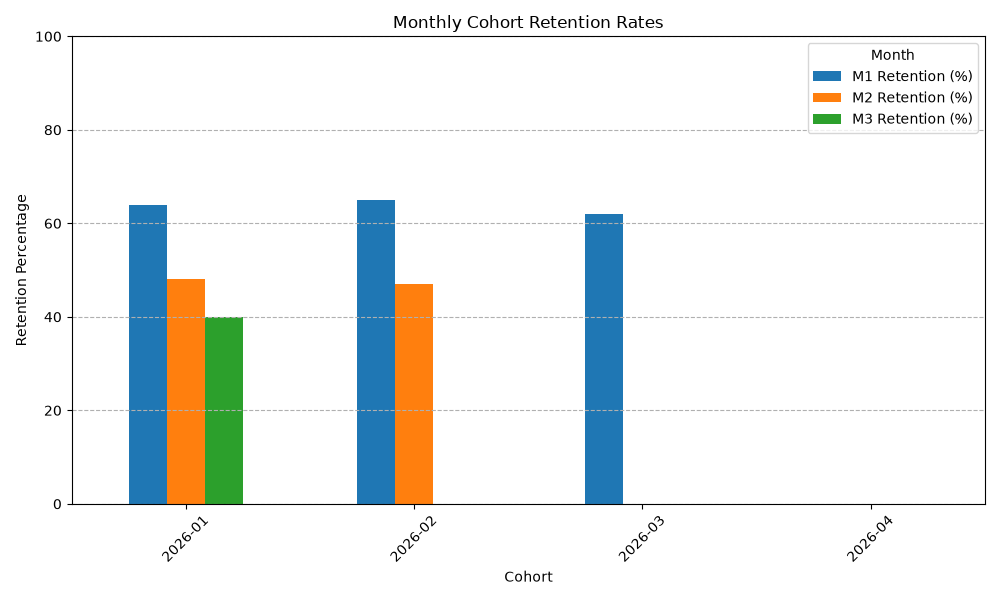


[files written: retention_chart.png, monthly_cohort_retention_2026.xlsx]


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data from the email
data = {
    'Cohort': ['2026-01', '2026-02', '2026-03', '2026-04'],
    'Size': [500, 620, 450, 700],
    'M1_retained': [320, 403, 279, None],
    'M2_retained': [240, 291, None, None],
    'M3_retained': [200, None, None, None]
}
df_raw = pd.DataFrame(data)

# Calculate retention percentages
df_retention = df_raw.copy()
df_retention['M1_retention_pct'] = (df_retention['M1_retained'] / df_retention['Size'] * 100).round(2)
df_retention['M2_retention_pct'] = (df_retention['M2_retained'] / df_retention['Size'] * 100).round(2)
df_retention['M3_retention_pct'] = (df_retention['M3_retained'] / df_retention['Size'] * 100).round(2)

# Prepare for retention triangle display
retention_triangle = df_retention[['Cohort', 'Size', 'M1_retention_pct', 'M2_retention_pct', 'M3_retention_pct']]
retention_triangle.columns = ['Cohort', 'Initial Size', 'M1 Retention (%)', 'M2 Retention (%)', 'M3 Retention (%)']

# Identify best performing cohort - based on M1 retention, then M2, then M3
# Fill None values with -1 for comparison purposes, then revert for display
retention_for_best = retention_triangle.fillna(-1)

best_cohort_m1 = retention_for_best.loc[retention_for_best['M1 Retention (%)'].idxmax()]
best_cohort_m2 = retention_for_best.loc[retention_for_best['M2 Retention (%)'].idxmax()]
best_cohort_m3 = retention_for_best.loc[retention_for_best['M3 Retention (%)'].idxmax()]

best_cohort_overall = retention_triangle.sort_values(by=['M3 Retention (%)', 'M2 Retention (%)', 'M1 Retention (%)'], ascending=False).iloc[0]

# Output to Excel
output_filename = '/tmp/output/monthly_cohort_retention_2026.xlsx'
with pd.ExcelWriter(output_filename, engine='xlsxwriter') as writer:
    retention_triangle.to_excel(writer, sheet_name='Retention Triangle', index=False)

    # Add summary for the best performing cohort
    summary_df = pd.DataFrame({
        'Metric': ['Overall Best Cohort'],
        'Cohort': [best_cohort_overall['Cohort']],
        'M1 Retention (%)': [best_cohort_overall['M1 Retention (%)']],
        'M2 Retention (%)': [best_cohort_overall['M2 Retention (%)']],
        'M3 Retention (%)': [best_cohort_overall['M3 Retention (%)']]
    })
    summary_df.to_excel(writer, sheet_name='Summary', index=False)

    # Create a chart
    df_chart = retention_triangle.set_index('Cohort')[['M1 Retention (%)', 'M2 Retention (%)', 'M3 Retention (%)']]
    ax = df_chart.plot(kind='bar', figsize=(10, 6))
    plt.title('Monthly Cohort Retention Rates')
    plt.ylabel('Retention Percentage')
    plt.xlabel('Cohort')
    plt.ylim(0, 100)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--')
    plt.legend(title='Month')
    plt.tight_layout()
    plt.savefig('/tmp/output/retention_chart.png')
    plt.close()

print(f"Retention analysis complete. Excel file and chart saved to {output_filename}")
print(retention_triangle.to_string())
print(f"\nOverall best performing cohort: {best_cohort_overall['Cohort']}")